<p style="font-family: Cambria; font-size: 30px;"><b>Descriptive Analysis</b></p>

In [1]:
#Importing all the Necessary Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import os
import seaborn as sns
from pathlib import Path
import warnings
warnings.simplefilter("ignore", UserWarning)

In [2]:
df = Path( r"C:\Numpy Ninja\Python hackathon sept 2026\cleaned_data")

<p style="font-family: Cambria; font-size: 16px;"><b>Question 1:</b></p>Does cardiac functional impairment, measured by NYHA class, correlate with elevated BNP and Troponin levels? (Association Between NYHA Severity Class and Cardiac Biomarkers) 

<p style="font-family: Cambria; font-size: 16px;"><b>Reasoning:</b></p> Connecting functional classification (NYHA) to blood markers (BNP and Troponin) validates clinical severity with quantitative lab metrics.

C:\Users\suche\AppData\Local\Temp\ipykernel_32260\3239087151.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\suche\AppData\Local\Temp\ipykernel_32260\3239087151.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


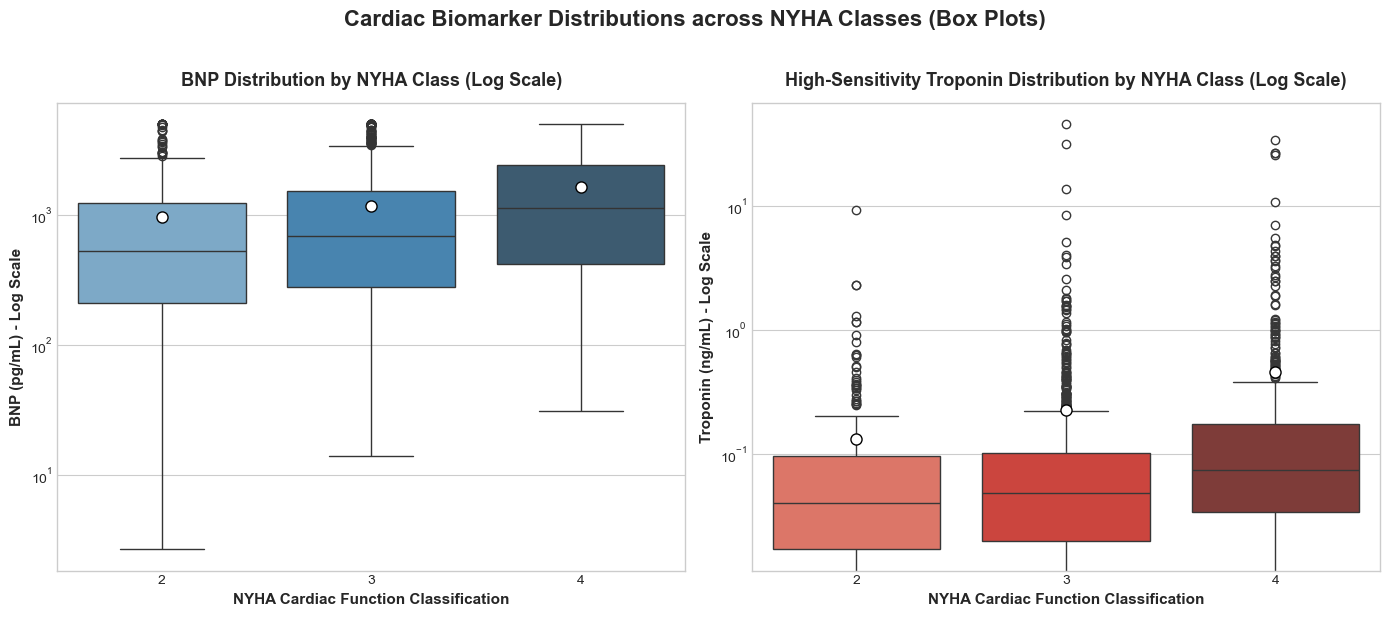

In [3]:
# 1. Load and merge datasets
cardiac = pd.read_csv(r'C:\Numpy Ninja\Python hackathon sept 2026\cleaned_data\Team7_CodeAvengers_Category1_DataCleaning_cardiac_complications.csv')
labs = pd.read_csv(r'C:\Numpy Ninja\Python hackathon sept 2026\cleaned_data\Team7_CodeAvengers_Category1_DataCleaning_labs.csv')

df = cardiac.merge(
    labs[['inpatient_number', 'high_sensitivity_troponin', 'brain_natriuretic_peptide']], 
    on='inpatient_number'
)

# 2. Filter valid NYHA classes
df = df[df['nyha_cardiac_function_classification'].isin([2, 3, 4, '2', '3', '4'])].copy()
df['nyha_cardiac_function_classification'] = df['nyha_cardiac_function_classification'].astype(str)

# 3. Define sequential order for X-axis
order = ['2', '3', '4']

# 4. Create side-by-side box plots with logarithmic scale
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Subplot 1: BNP Box Plot
sns.boxplot(
    data=df, 
    x='nyha_cardiac_function_classification', 
    y='brain_natriuretic_peptide', 
    order=order,  # Enforces 2 -> 3 -> 4 order
    ax=axes[0], 
    palette="Blues_d",
    showmeans=True,
    meanprops={"marker": "o", "markerfacecolor": "white", "markeredgecolor": "black", "markersize": "8"}
)
axes[0].set_yscale('log')
axes[0].set_title('BNP Distribution by NYHA Class (Log Scale)', fontsize=13, fontweight='bold', pad=12)
axes[0].set_xlabel('NYHA Cardiac Function Classification', fontsize=11, fontweight='bold')
axes[0].set_ylabel('BNP (pg/mL) - Log Scale', fontsize=11, fontweight='bold')

# Subplot 2: High-Sensitivity Troponin Box Plot
sns.boxplot(
    data=df, 
    x='nyha_cardiac_function_classification', 
    y='high_sensitivity_troponin', 
    order=order,  # Enforces 2 -> 3 -> 4 order
    ax=axes[1], 
    palette="Reds_d",
    showmeans=True,
    meanprops={"marker": "o", "markerfacecolor": "white", "markeredgecolor": "black", "markersize": "8"}
)
axes[1].set_yscale('log')
axes[1].set_title('High-Sensitivity Troponin Distribution by NYHA Class (Log Scale)', fontsize=13, fontweight='bold', pad=12)
axes[1].set_xlabel('NYHA Cardiac Function Classification', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Troponin (ng/mL) - Log Scale', fontsize=11, fontweight='bold')

# Overall formatting
fig.suptitle('Cardiac Biomarker Distributions across NYHA Classes (Box Plots)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()

# Save image and render
plt.savefig('nyha_biomarkers_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()



<p style="font-family: Cambria; font-size: 16px;"><b>Key Insight:</b></p>

113% BNP Surge (Wall Stress): Median BNP jumps from 529.8 to 1,130.3 pg/mL as severity increases from Class 2 to 4, showing double the fluid overload.   

85% Troponin Rise (Heart Damage): Median Troponin climbs from 0.040 to 0.074 ng/mL, proving ongoing myocardial tissue damage across all classes.   

High Outlier Spike (Decompensation): Means (white dots) sit much higher than medians (e.g., Class 4 BNP mean is 1,638.6 pg/mL), pinpointing acute high-risk patient spikes.   

<p style="font-family: Cambria; font-size: 16px;"><b>Question 2:</b></p> How drastically do serum Creatinine, Urea, and eGFR change in patients diagnosed with Acute Renal Failure?
(Renal Function Impairment in Acute Renal Failure Cases)

<p style="font-family: Cambria; font-size: 16px;"><b>Reasoning:</b></p>Evaluates kidney biomarker degradation when acute kidney injury/failure is recorded in patient medical history.

C:\Users\suche\AppData\Local\Temp\ipykernel_32260\3068051420.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_plot, x='acute_renal_failure_label', y=col, ax=axes[idx], palette=palette)
C:\Users\suche\AppData\Local\Temp\ipykernel_32260\3068051420.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_plot, x='acute_renal_failure_label', y=col, ax=axes[idx], palette=palette)
C:\Users\suche\AppData\Local\Temp\ipykernel_32260\3068051420.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_plot, x='acute_renal_failure_la

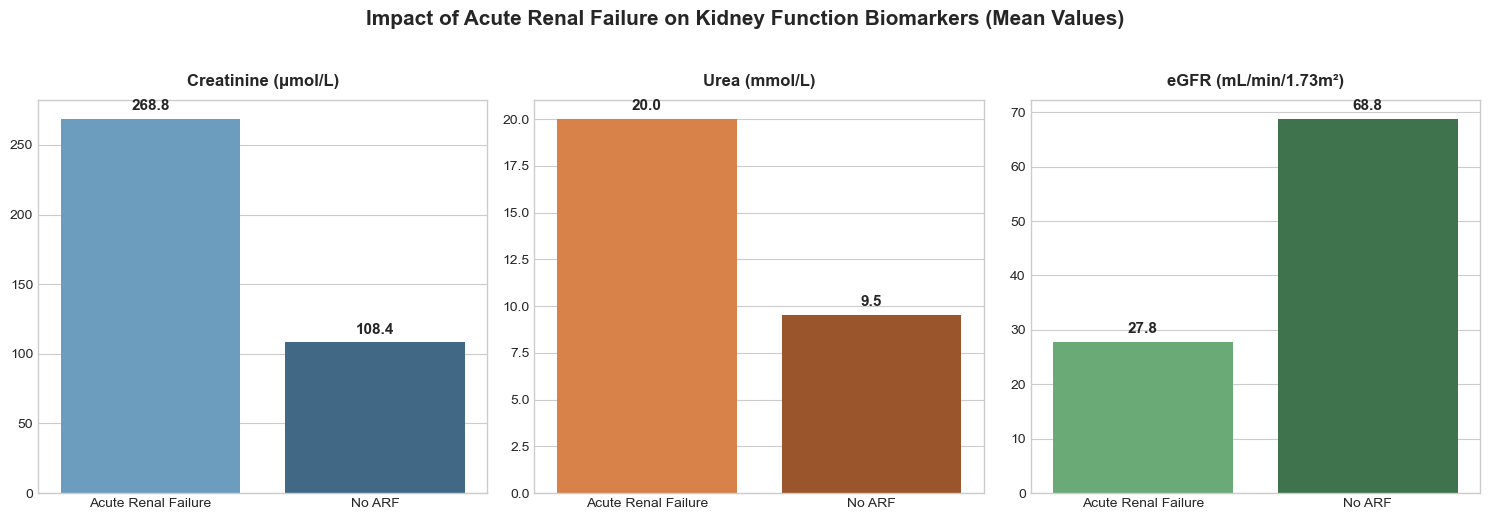

In [5]:
# 1. Load and merge datasets
history = pd.read_csv(r"C:\Numpy Ninja\Python hackathon sept 2026\cleaned_data\Team7_CodeAvengers_Category1_DataCleaning_patienthistory_cleaned.csv")
labs = pd.read_csv(r"C:\Numpy Ninja\Python hackathon sept 2026\cleaned_data\Team7_CodeAvengers_Category1_DataCleaning_labs.csv")

merged_q4 = history.merge(
    labs[['inpatient_number', 'creatinine_enzymatic_method', 'urea', 'glomerular_filtration_rate']], 
    on='inpatient_number'
)

# 2. Map categorical labels
merged_q4['acute_renal_failure_label'] = merged_q4['acute_renal_failure'].map({0: 'No ARF', 1: 'Acute Renal Failure'})

# 3. Create 3-panel bar charts
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics = [
    ('creatinine_enzymatic_method', 'Creatinine (μmol/L)', 'Blues_d'),
    ('urea', 'Urea (mmol/L)', 'Oranges_d'),
    ('glomerular_filtration_rate', 'eGFR (mL/min/1.73m²)', 'Greens_d')
]

for idx, (col, title, palette) in enumerate(metrics):
    df_plot = merged_q4.groupby('acute_renal_failure_label')[col].mean().reset_index()
    sns.barplot(data=df_plot, x='acute_renal_failure_label', y=col, ax=axes[idx], palette=palette)
    axes[idx].set_title(title, fontsize=12, fontweight='bold', pad=10)
    axes[idx].set_xlabel('', fontsize=10)
    axes[idx].set_ylabel('', fontsize=10)
    
    # Add numerical value labels on top of bars
    for p in axes[idx].patches:
        h = p.get_height()
        if not pd.isna(h):
            axes[idx].annotate(f'{h:.1f}', (p.get_x() + p.get_width() / 2., h),
                               ha='center', va='bottom', fontsize=11, fontweight='bold',
                               xytext=(0, 4), textcoords='offset points')

fig.suptitle('Impact of Acute Renal Failure on Kidney Function Biomarkers (Mean Values)', fontsize=15, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('arf_kidney_biomarkers_barchart.png', dpi=300, bbox_inches='tight')
plt.show()

<p style="font-family: Cambria; font-size: 16px;"><b>Key Insight:</b></p>Creatinine (+148% increase): Jumps from an average of 108.4 μmol/L (No ARF) to 268.8 μmol/L (ARF).

Urea (+110% increase): More than doubles from 9.5 mmol/L (No ARF) to 20.0 mmol/L (ARF).

eGFR (-60% drop): Drops severely from 68.8 mL/min/1.73m² (No ARF) down to 27.8 mL/min/1.73m² (ARF), indicating severe loss of kidney filtration capability.